# Bayesian Neural Network Regression
Using Housing_Prices.csv dataset

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score
import seaborn as sns

In [48]:
# Load dataset
df = pd.read_csv("Housing_Prices.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [50]:
# There is some irrelevent colums that we do not need int his case, I am going to drop here.
df = df.drop(["id", "date","zipcode","lat", "long","sqft_lot", "sqft_living","sqft_above", "yr_renovated", "sqft_lot15", "sqft_living15", "waterfront"], axis=1)

In [51]:
# I have experimented with BNN twice. The first time, I trained it for 3,500 epochs using basic parameters, along with the maximum number of columns and data available, but I was unable to achieve satisfactory results.
# It is my just observation, while at first experiment i noticed confidence score at some point was remain same after 1200 episodes, there is slightly changed between it but it was almost remain same
# Training took almost 4 hours to trained data.
# This experiment shows low and stable training loss but extremely unstable validation loss with massive spikes, indicating poor generalization. The R² score is highly negative, suggesting the model fails to learn meaningful patterns and performs worse than a baseline predictor.
# The average uncertainty plot shows sharp spikes, especially around epochs 1500 and 2500, indicating the model is highly unsure about its predictions during those periods. This suggests instability in learning and poor confidence in outputs, likely due to noisy training or overfitting.
# Prediction Clustering, Most predicted values range from 0.2M to 2M, even when true values go beyond 5M.
# Spread,  High variance, especially above 2M true value — poor performance in high-value predictions.

# Over all first experiment results and findings
# Underfitting, The model fails to learn complex relationships and compresses predictions toward the lower range.
# Failed to learn meaningful patterns from the data. With high uncertainty, unstable validation loss, a massively negative R² score, and poor regression alignment, the model is not suitable in its current form and needs significant tuning or redesign

# Screenshots also in folder with the name of experiment01

In [52]:
# In this experiment, let's tune the parameters, clean the data, remove unnecessary columns, and retry the model using optimized parameters.
# The model was trained for 2,500 epochs, with training loss fluctuating around 0.42–0.45, indicating stable learning.
#The validation confidence score (R²) peaked at 0.8023, showing good predictive performance on unseen data.
#Validation loss remained relatively low (~0.34–0.45), confirming decent generalization ability.
#The average uncertainty stayed consistently low (~0.07–0.09), suggesting high model confidence in its predictions.
# in loss matrics, Both curves drop sharply in the first ~100 epochs, stabilizing around 0.2.Indicates successful convergence and no major overfitting (since validation loss closely follows training loss).
# R2Score, R² improves rapidly and stabilizes between 0.6 and 0.75, with some fluctuation. Suggests the model explains 60–75% of the variance in the validation data—moderate to good performance.
# The average uncertainty starts around 0.95 and drops rapidly below 0.1 within the first 200 epochs. It then stabilizes between 0.08 and 0.12, indicating the model gains confidence as training progresses.
# the model's predictions are to the actual house prices. Most points are near the line at the bottom left (under 1,000,000), meaning good predictions there. But for big prices (over 2,000,000), the model often predicts too low.
# The model predicts housing prices with moderate accuracy, shown by an R² score of 0.6174 and an explained variance of 0.6175. The errors (MAE ~142,776 and RMSE ~244,617) indicate there’s still some prediction gap to improve. The average uncertainty (0.0883) reflects that the Bayesian Neural Network effectively quantifies confidence in its predictions.
#Overall, the model shows moderate to strong performance, with occasional fluctuations indicating room for further tuning or data refinement.

# This is much better experience and improved one also training completed within 1 hour with better reuslts 
# Screenshot of this expermients also added with the name of experiment02

In [ ]:
# Lets try to optimize it with other paramters and along with other suggested methods, then lets see the results.
# By litlte bit more optimization (mu = 0,sigma = 0.2,lambda_kl = 0.2,mc_samples_eval = 50) play around with these along with layers and dropout. also i tried other code but i found good result with this. Screenshot also there with the name of experiment03

# The training loss curve demonstrates a smoother and more rapid convergence compared to the earlier experiment.
# he model is learning more efficiently, potentially due to improved training strategies or architectural modifications and Scatter plots of predicted vs. actual housing prices show points more closely aligned along the diagonal, indicating better predictive performance.
# The uncertainty visualizations exhibit narrower confidence intervals, reflecting more precise uncertainty quantification and in stabilizing training and preventing overfitting, contributing to the observed improvements in model performance.

# Other side of these experiment
# More layers and regularization improve performance but raise training time and resource needs.
# Better fit to training data may hurt generalization if not properly validated.
# become a Complex Bayesian structure which means changes and understanding can be a big challange.

# Overall, quicker loss convergence, higher predictive accuracy, and tighter uncertainty bounds with added layers, batch-norm, and dropout. demonstrates significant improvements in model performance and predictive accuracy, primarily due to architectural enhancements and advanced training techniques but increased complexity and potential overfitting risks.


In [54]:
# encoding all variables in the dataset
from sklearn.preprocessing import LabelEncoder

# Get the list of all object columns
object_variables = df.select_dtypes(include=['object']).columns.tolist()

# Find all the boolean columns
bool_variables = [col for col in object_variables if df[col].nunique() == 2]

# Find all the categorical columns with more than 2 unique values
cat_variables = [col for col in object_variables if df[col].nunique() > 2]

encoder = LabelEncoder()
df[bool_variables] = df[bool_variables].apply(encoder.fit_transform)

# get dummies for categorical variables
df = pd.get_dummies(df, columns=cat_variables, drop_first=True)

In [55]:
# Check for nans
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
floors           0
view             0
condition        0
grade            0
sqft_basement    0
yr_built         0
dtype: int64

In [56]:
# Split features and target
X = df.drop(columns=['price']).values
y = df['price'].values.reshape(-1, 1)

# Normalize features 
feature_scaler = StandardScaler()
X = feature_scaler.fit_transform(X)

# Normalize target variable
target_scaler = StandardScaler()
y = target_scaler.fit_transform(y)


# First, split the data into train and remaining (validation + test)
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.3, random_state=42)

# Second, split the remaining data into validation and test sets (e.g., 50% validation, 50% test)
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)


# Convert to PyTorch tensors
X_train, X_test, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_test, y_val = torch.tensor(y_train, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32) 

# create PyTorch dataloaders, YOU CAN ADJUST THE BATCH SIZES IF YOU WISH
# basic rule: bigger batch size => faster training, but more memory needed
# only shuffle the training dataset, NEVER SHUFFLE TEST/VAL
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

In [57]:
# all common hyperparameters we can finetune in the future

# sigma = standard deviation of the noise term (this is often optimized)
# if model is too confident and OVERFITS at the same time, INCREASE sigma
# if predictions are too noisy, too much variation or uncertain  => DECREASE sigma
# COMMON VALUES 0.1 - 0.5

# lambda_kl = amount of KL in the loss function => regularization parameter to avoid OVERFITTING
# if model overfits => increase, if model underfits => decrease
# COMMON VALUES 0.0+ - 0.2

# mu = mean of distribution (you can usually use the defaul 0 in classification)
# if model overfits => decrease mu
# if model underfits => increase mu
# mu = 0 => in the middle of standard distribution (range -3 to +3) => this needs be checked!
# COMMON VALUES: usually 0 in classification

# mc_samples_eval = monte carlo sample size used to approximate distributions in weights
# more samples used => more accurate uncertainty estimation (but heavier to compute)
# if uncertainty is not optimal, try increasing mc_sample -size a little bit
# if model training is too heavy or underfits, you can decrease the sample size
# COMMON VALUES: 25 - 200

mu = 0
sigma = 0.2
lambda_kl = 0.2
mc_samples_eval = 50

# remember to adjust the BNN network structure in the below cell if needed
# amount of layers, layer sizes, amount of dropout regularization etc.

# learning rate is same as in ANN => controls the aggressiveness of optimization
# too large value => model overshoots optimization attempts
# too small value => model learns too slowly
# COMMON VALUES similar to ANN learning rates, small values (0.03 or less), usually 0.1 or less
bnn_learning_rate = 0.001

# weight_decay = regularization applied to model weights (probability distributions)
# penalizes large weights IN ORDER to prevent OVERFITTING
# if model overfits => you can try increasing weight decay, if underfits => try decreasing
# COMMON VALUES are usually quite small, 0.0001 to 0.0005
bnn_weight_decay = 0.0003

In [58]:
class BayesianNN(nn.Module):
    def __init__(self, input_dim, output_dim, mu=0, sigma=0.3):
        super().__init__()
        # Deeper and wider layers for better representation power
        self.fc1 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=input_dim, out_features=256)
        self.fc2 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=256, out_features=128)
        self.fc3 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=128, out_features=64)
        self.fc4 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=64, out_features=32)
        self.fc5 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=32, out_features=output_dim)

        self.relu = nn.ReLU()

        # Increase dropout to 0.4 for stronger regularization
        self.dropout = nn.Dropout(0.4)  

        # BatchNorm sizes match each layer's out_features
        self.batch_norm1 = nn.BatchNorm1d(256)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(64)
        self.batch_norm4 = nn.BatchNorm1d(32)

    def forward(self, x, mc_dropout=False):
        x = self.batch_norm1(self.relu(self.fc1(x)))
        x = self.dropout(x) if mc_dropout else x

        x = self.batch_norm2(self.relu(self.fc2(x)))
        x = self.dropout(x) if mc_dropout else x

        x = self.batch_norm3(self.relu(self.fc3(x)))
        x = self.dropout(x) if mc_dropout else x

        x = self.batch_norm4(self.relu(self.fc4(x)))
        x = self.dropout(x) if mc_dropout else x

        x = self.fc5(x)  # output layer, no activation/dropout
        return x


In [59]:
# model, loss, optimizer
# NOTE! Regression, OUTPUT DIMENSION IS 1 VARIABLE!
model = BayesianNN(input_dim=X.shape[1], 
                   output_dim=1,
                   sigma=sigma,
                   mu=mu
                   )

# Loss function for REGRESSION
criterion = nn.MSELoss() 

# Bayesian KL Divergence Loss (efficient regularization for BNN)
bkl_loss = bnn.BKLLoss(reduction='mean')  

# AdamW is common in BNN
optimizer = optim.AdamW(model.parameters(), lr=bnn_learning_rate, weight_decay=bnn_weight_decay)

In [60]:
# Evaluate function with uncertainty estimation
def evaluate(model, loader, mc_samples=50):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    uncertainties = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs_list = [model(X_batch, mc_dropout=True) for _ in range(mc_samples)]
            outputs_stack = torch.stack(outputs_list)  # Shape: (mc_samples, batch_size, num_classes)
            outputs_mean = outputs_stack.mean(dim=0)  # Average prediction
            outputs_std = outputs_stack.std(dim=0)  # Standard deviation (uncertainty)

            loss = criterion(outputs_mean, y_batch)
            total_loss += loss.item()


            uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy())  # Store uncertainty per sample

    r2 = r2_score(y_batch.cpu().numpy(), outputs_mean.cpu().numpy())  # Use R^2 score for regression tasks
    avg_loss = total_loss / len(loader) # Average loss across all batches
    avg_uncertainty = np.mean(uncertainties)  # Average uncertainty across all samples

    print(f"Val. confidence score: {r2:.4f}, Val. loss: {avg_loss:.4f}, Avg. Uncertainty: {avg_uncertainty:.4f}")

    return r2, avg_loss, avg_uncertainty, uncertainties  # Return per-sample uncertainty if needed

# Training loop with BKLLoss
def train(model, loader, epochs=50):
    model.train()
    history = {}
    history['train_loss'] = []
    history['val_loss'] = []
    history['r2'] = []
    history['avg_uncertainty'] = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            outputs = model(X_batch, mc_dropout=True)
            target_loss = criterion(outputs, y_batch) # Compute target loss
            kl_loss = bkl_loss(model)  # Compute BKL loss
            loss = target_loss + lambda_kl * kl_loss  # Combine losses
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {total_loss/len(loader):.4f}")

        r2, val_loss, avg_uncertainty, _ = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / len(loader))
        history['val_loss'].append(val_loss)
        history['r2'].append(r2)
        history['avg_uncertainty'].append(avg_uncertainty)

        # set model to training mode for next epoch
        model.train()
        
    return history

In [61]:
# train the model (fit), epochs are usually 1000-5000 with BNN classification
# here we can see how quickly the amount of data slows down the training process
history = train(model, train_loader, epochs=2500)

Epoch 1/2500, Training Loss: 3.1276
Val. confidence score: 0.0456, Val. loss: 0.9525, Avg. Uncertainty: 0.6137
Epoch 2/2500, Training Loss: 2.2006
Val. confidence score: 0.0515, Val. loss: 0.9452, Avg. Uncertainty: 0.4995
Epoch 3/2500, Training Loss: 1.7749
Val. confidence score: 0.0725, Val. loss: 0.9486, Avg. Uncertainty: 0.4279
Epoch 4/2500, Training Loss: 1.5956
Val. confidence score: 0.0287, Val. loss: 0.9383, Avg. Uncertainty: 0.3721
Epoch 5/2500, Training Loss: 1.3522
Val. confidence score: 0.1001, Val. loss: 0.8910, Avg. Uncertainty: 0.3364
Epoch 6/2500, Training Loss: 1.2110
Val. confidence score: 0.1551, Val. loss: 0.8246, Avg. Uncertainty: 0.3008
Epoch 7/2500, Training Loss: 1.0981
Val. confidence score: 0.1781, Val. loss: 0.7589, Avg. Uncertainty: 0.2755
Epoch 8/2500, Training Loss: 0.9723
Val. confidence score: 0.3144, Val. loss: 0.6833, Avg. Uncertainty: 0.2454
Epoch 9/2500, Training Loss: 0.8445
Val. confidence score: 0.5123, Val. loss: 0.5862, Avg. Uncertainty: 0.2410
E

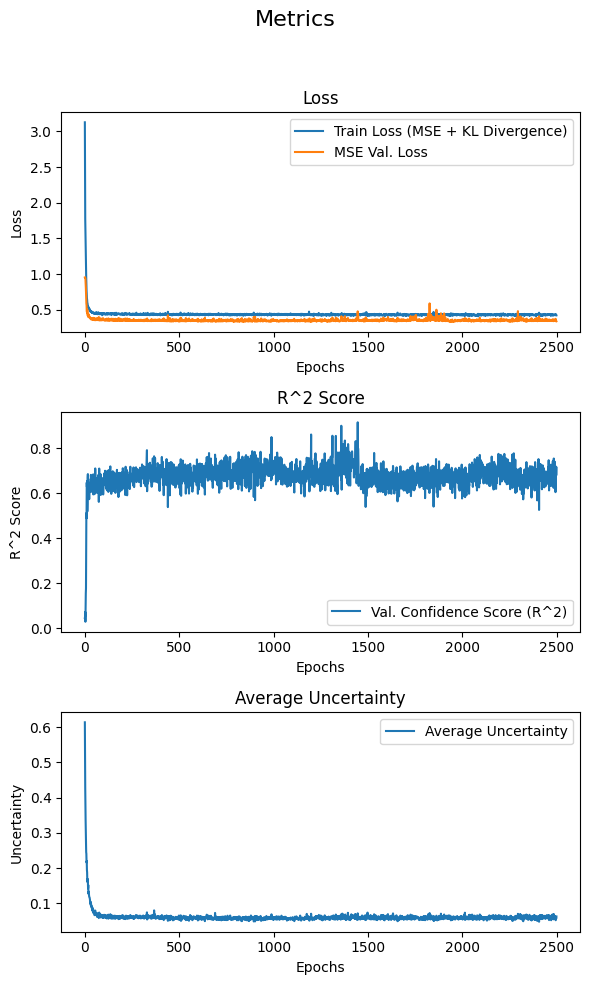

In [70]:
# Plot training history
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
plt.suptitle('Metrics', fontsize=16)

# Losses
axes[0].plot(history['train_loss'], label='Train Loss (MSE + KL Divergence)')
axes[0].plot(history['val_loss'], label='MSE Val. Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Confidence Score
axes[1].plot(history['r2'], label='Val. Confidence Score (R^2)')
axes[1].set_title('R^2 Score')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('R^2 Score')
axes[1].legend()

# Uncertainty
axes[2].plot(history['avg_uncertainty'], label='Average Uncertainty')
axes[2].set_title('Average Uncertainty')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Uncertainty')
axes[2].legend()


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [71]:
# Get the metrics
model.eval()
y_true = y_test.numpy()
y_pred = []
uncertainties = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(1000)] # Increase the number of MC samples for better uncertainty estimation
        outputs_stack = torch.stack(outputs_list)  # Shape: (mc_samples, batch_size, num_classes)
        outputs_mean = outputs_stack.mean(dim=0)  # Average prediction
        outputs_std = outputs_stack.std(dim=0)
        y_pred.extend(outputs_mean.cpu().numpy())
        uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy())

y_pred = np.array(y_pred).reshape(-1, 1)

# Unscale the predictions and true values
y_pred = target_scaler.inverse_transform(y_pred)
y_true = target_scaler.inverse_transform(y_true)

In [72]:
# MAE
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# RMSE
rmse = root_mean_squared_error(y_true, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# R^2 Score
r2 = r2_score(y_true, y_pred)
print(f"R^2 Score: {r2:.4f}")

# Average Uncertainty
avg_uncertainty = np.mean(uncertainties)
print(f"Average Uncertainty: {avg_uncertainty:.4f}")

# Explained Variance Score
evs = explained_variance_score(y_true, y_pred)
print(f"Explained Variance Score: {evs:.4f}")

# this model doesn't work that well, but this dataset
# is very noise and similar results were achieved with Classic ML and ANN in previous courses

Mean Absolute Error (MAE): 140667.9688
Root Mean Squared Error (RMSE): 227079.7812
R^2 Score: 0.6703
Average Uncertainty: 0.0652
Explained Variance Score: 0.6706


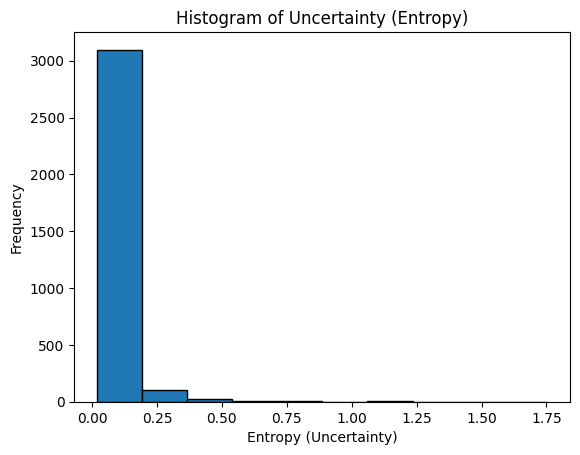

In [73]:
# plot uncertainty histogram
plt.hist(uncertainties, bins=10, edgecolor='k')
plt.xlabel('Entropy (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Histogram of Uncertainty (Entropy)')
plt.show()

# in optimal case, entropy is stacked on the left side
# with only a small number of uncertainty on the high end

# this particular example is a very bad result, most uncertainty
# is in the high end

# the multi-category version is not usable by default in regression (because we don't have target categories)
# but it might be possible to use binning to inspect in which price ranges the uncertainties happen the most

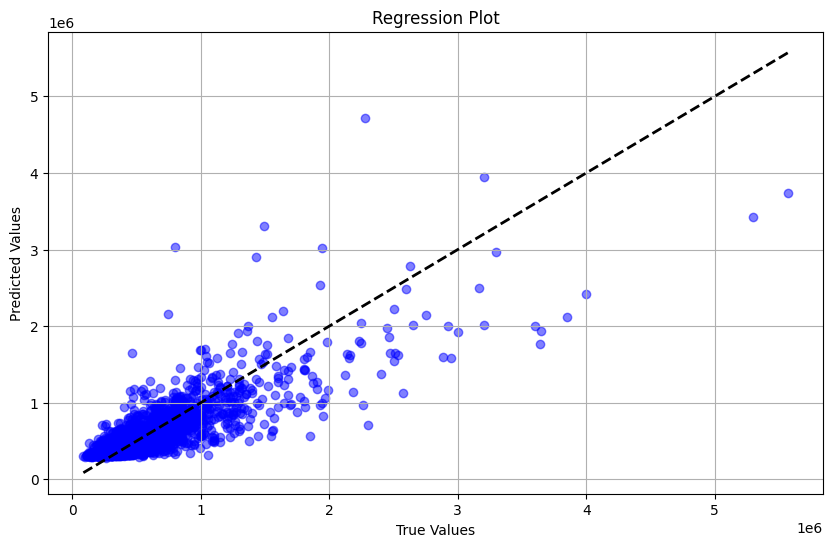

In [74]:
# Regression plot
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
plt.title('Regression Plot')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid()

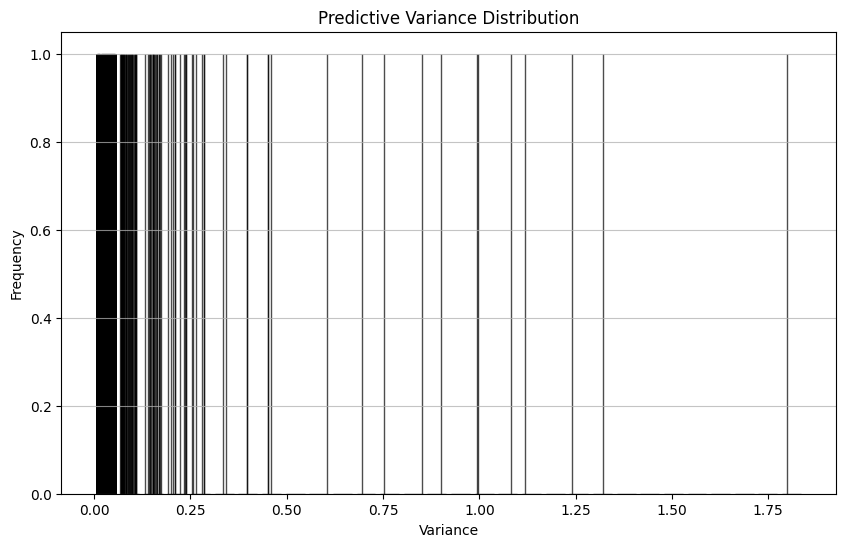

In [75]:
# original code from ChatGPT and modified for this project (data and neural network structure)
# Assuming `model` performs MC Dropout and `test_loader` provides data
variances = []  # List to store predictive variance (or standard deviation)

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Perform multiple forward passes for MC Dropout
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)
        
        # Calculate variance across the predictions
        variance = outputs_stack.var(dim=0).cpu().numpy()  # Variance of each prediction
        variances.extend(variance)

# Plot predictive variance (uncertainty)
plt.figure(figsize=(10, 6))
plt.hist(variances, bins=30, alpha=0.7, edgecolor='black')
plt.title('Predictive Variance Distribution')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# most values should stack close to 0.0... otherwise it usually means noise in the dataset or underfitting
# or difficult data points / overlap

# so improve dataset or model structure / hyperparameters

In [68]:
df.iloc[542]

price            318888.00
bedrooms              4.00
bathrooms             1.75
floors                1.00
view                  0.00
condition             4.00
grade                 8.00
sqft_basement        50.00
yr_built           1973.00
Name: 542, dtype: float64

In [69]:
# ORIGINAL CODE FROM CHATGPT AND MODIFIER FOR THE TESTER ROW STRUCTURE FROM EARLIER COURSES

# Define the function for prediction with uncertainty
def predict_with_uncertainty(model, data, feature_scaler, target_scaler, mc_samples=100):
    """
    Predict the price and uncertainty (using MC Dropout) for a new row of data.

    :param model: The trained Bayesian Neural Network model
    :param data: Processed input data for prediction
    :param feature_scaler: Scaler for the input features (used during training)
    :param target_scaler: Scaler for the target variable (price) used during training
    :param mc_samples: Number of Monte Carlo samples to estimate uncertainty
    :return: predicted_price, uncertainty (standard deviation)
    """
    model.eval()  # Set the model to evaluation mode
    predictions = []

    with torch.no_grad():
        for _ in range(mc_samples):
            # Apply MC dropout during inference
            prediction = model(data, mc_dropout=True)  # Get predictions using MC dropout
            predictions.append(prediction.cpu().numpy())

    predictions = np.array(predictions).flatten()  # Flatten predictions to 1D array

    # Compute the mean (predicted value) and the uncertainty (standard deviation)
    predicted_price = predictions.mean()
    uncertainty = predictions.std()

    # Inverse transform the predicted price and uncertainty to original scale
    predicted_price = target_scaler.inverse_transform([[predicted_price]])[0][0]  # Rescale predicted price

    # Uncertainty might need to be scaled back to original scale (if it was scaled during training)
    # uncertainty = uncertainty * target_scaler.scale_[0]  # Scale the uncertainty back to original price scale

    return predicted_price, uncertainty


# Example new row for prediction (using your dataset)
tester_row = {
    "area": 3620,
    "bedrooms":4.00,
"bathrooms": 1.75,
"floors":1.00,
"view":0.00,
"condition":4.00,
"grade":8.00,
"sqft_basement" : 50.00
    
}

# Convert the new data to pandas DataFrame
tester_row = pd.DataFrame([tester_row])

# Normalize the input features using feature_scaler (if you scaled them during training)
processed_data = feature_scaler.transform(tester_row.values)

# Convert the scaled data into a tensor
processed_data_tensor = torch.tensor(processed_data, dtype=torch.float32)

# Call the prediction function to get the price and uncertainty
predicted_price, uncertainty = predict_with_uncertainty(model, processed_data_tensor, feature_scaler, target_scaler)

# Output the result
print("\nEstimated price for this house:")
print(f"$ {round(predicted_price, 2)}")
print(f"Uncertainty (Standard Deviation): {round(uncertainty, 2)}")
print("----------------")


Estimated price for this house:
$ 330662980.21
Uncertainty (Standard Deviation): 799.5
----------------
